Loading parameters from: /Users/Chiara/Documents/Documents_Chiara_MacBook_Air/Education : Personal Projects : Studies/Heat Transfer/july_params.json
  Location    : Boulder, CO  |  Month : 1
  N harmonics : 2
  Temp RMSE   : 0.3829 K
  GHI  RMSE   : 2.3698 W/m²
  Indoor BC   : fixed_Ts  (T_s,in = 20.0 °C)

Grid  : 146 nodes, wall = 15.0 cm
Solver: 1440 steps × 60 s = 24 h

Simulation complete  [fixed_Ts]
  Indoor surface  T = 20.00 °C
  Outdoor surface T = -2.04 °C
  Indoor surface prescribed at 20.0 °C (Dirichlet BC)
  Cumulative wall flux into room : 533.19 Wh/m²


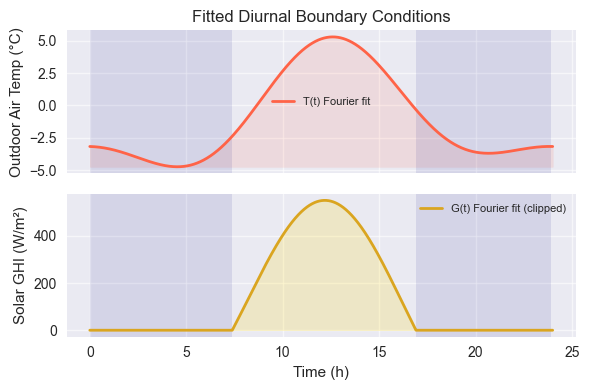

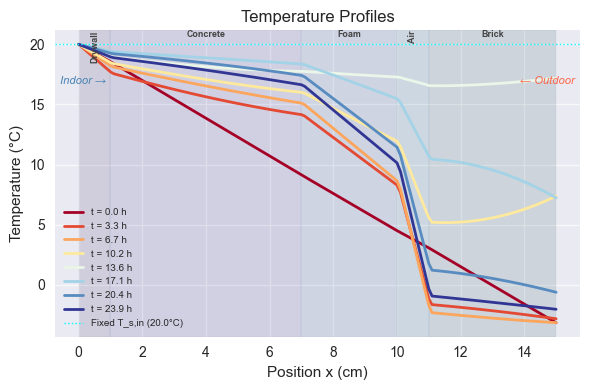

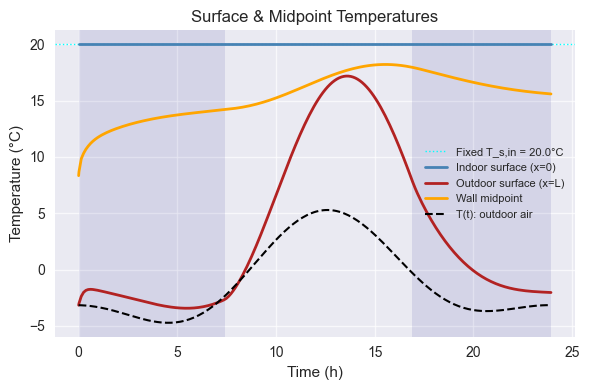

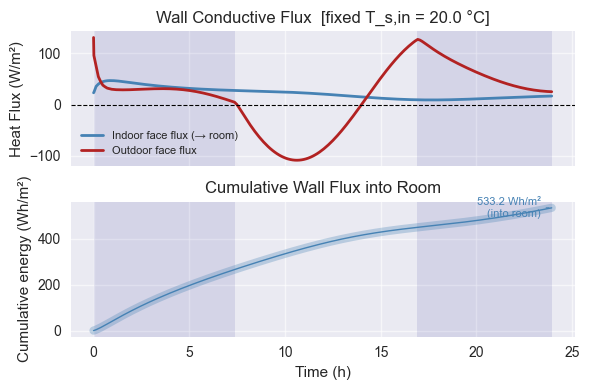

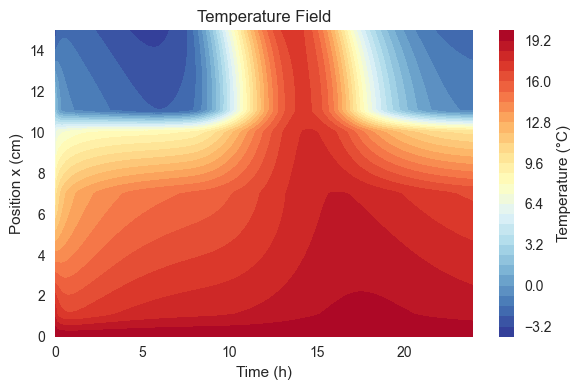

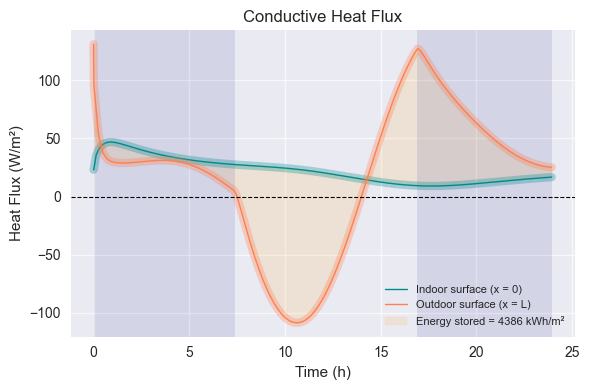

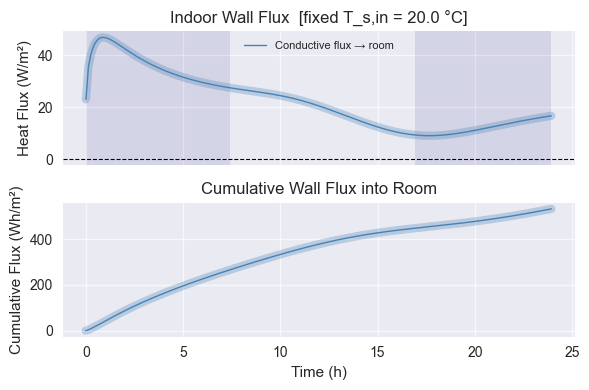

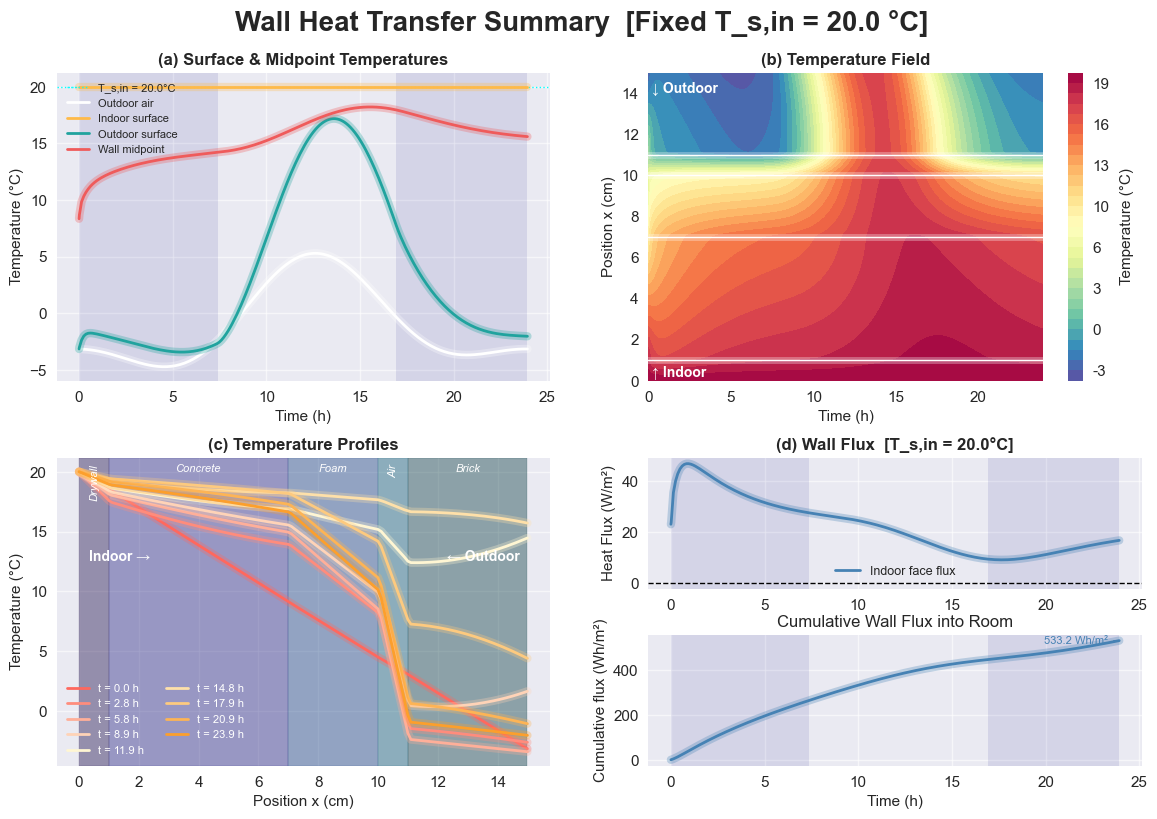

Figure 7 saved: 07_summary_figure.png

  Location: Boulder, CO  |  Month : 1
  Mode    : fixed_Ts
  Wall: Drywall, Concrete, Foam, Air, Brick
  R-value: 1.0301 m²·K/W  (U = 0.971 W/m²·K)
  Fixed indoor surface T: 20.0 °C
  Cumulative wall flux → room : 533.19 Wh/m²

All plots saved to: /Users/Chiara/Documents/Documents_Chiara_MacBook_Air/Education : Personal Projects : Studies/Heat Transfer


In [5]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LinearSegmentedColormap

# =============================================================================
# CONFIGURATION
# =============================================================================
OUT_DIR = "/Users/Chiara/Documents/Documents_Chiara_MacBook_Air/Education : Personal Projects : Studies/Heat Transfer"

# =============================================================================
# INDOOR BOUNDARY CONDITION MODE
# =============================================================================
# "comfort_band" : dynamic room air temperature with HVAC clamping (Robin BC).
#                  The wall surface temperature floats freely; HVAC acts on the
#                  room air to keep it within [T_comfort_lo, T_comfort_hi].
#
# "fixed_Ts"     : prescribed indoor wall surface temperature (Dirichlet BC).
#                  T_room and HVAC are irrelevant and skipped entirely.
#                  Set T_indoor_surface_C below to the desired value in °C.

INDOOR_BC_MODE = "fixed_Ts"   # "comfort_band"  |  "fixed_Ts"
T_INDOOR_SURFACE_C   = 20.0             # [°C] used only when INDOOR_BC_MODE == "fixed_Ts"

# =============================================================================
# LOAD FITTED FOURIER PARAMETERS
# =============================================================================
json_path = os.path.join(OUT_DIR, "july_params.json")
print(f"Loading parameters from: {json_path}")

with open(json_path) as f:
    params = json.load(f)

N_HARM   = params["n_harmonics"]
T_PER    = params["period_s"]
coeffs_T = np.array(params["temperature"]["coeffs"])
coeffs_G = np.array(params["solar"]["coeffs"])
loc      = params["location"]["name"]
month    = params["month"]

print(f"  Location    : {loc}  |  Month : {month}")
print(f"  N harmonics : {N_HARM}")
print(f"  Temp RMSE   : {params['temperature']['rmse_K']:.4f} K")
print(f"  GHI  RMSE   : {params['solar']['rmse_Wm2']:.4f} W/m²")
print(f"  Indoor BC   : {INDOOR_BC_MODE}"
      + (f"  (T_s,in = {T_INDOOR_SURFACE_C:.1f} °C)" if INDOOR_BC_MODE == "fixed_Ts" else ""))

# =============================================================================
# DIURNAL BOUNDARY CONDITION FUNCTIONS
# =============================================================================

def fourier_eval_scalar(t_clock, coeffs, n_harm, period):
    val = coeffs[0]
    for n in range(1, n_harm + 1):
        val += coeffs[2*n - 1] * np.cos(2 * np.pi * n * t_clock / period)
        val += coeffs[2*n    ] * np.sin(2 * np.pi * n * t_clock / period)
    return val

def T_inf_func(t_sim, t_start_of_day=0.0):
    t_clock = (t_start_of_day + t_sim) % T_PER
    return fourier_eval_scalar(t_clock, coeffs_T, N_HARM, T_PER)

def G_sun_func(t_sim, t_start_of_day=0.0):
    t_clock = (t_start_of_day + t_sim) % T_PER
    return max(fourier_eval_scalar(t_clock, coeffs_G, N_HARM, T_PER), 0.0)

def fourier_eval_vec(t_arr, coeffs, n_harm, period):
    val = np.full_like(t_arr, coeffs[0], dtype=float)
    for n in range(1, n_harm + 1):
        val += coeffs[2*n - 1] * np.cos(2 * np.pi * n * t_arr / period)
        val += coeffs[2*n    ] * np.sin(2 * np.pi * n * t_arr / period)
    return val

# =============================================================================
# WALL LAYER DEFINITIONS
# =============================================================================
LAYERS = [
    {"name"      : "Drywall",
        "thickness" : 0.01,        # [m] Thickness of layer
        "k"         : 0.16,        # [W/mK] Thermal conductivity of material
        "rho"       : 950,         # [kg/m³] Density of material
        "cp"        : 850,         # [J/kgK] Specific heat capacity
        "nodes"     : 10},         # Number of points to evaluate along x
    {"name"      : "Concrete",
        "thickness" : 0.06,
        "k"         : 0.5,
        "rho"       : 2400.0,
        "cp"        : 1050.0,
        "nodes"     : 60},
    {"name"      : "Foam",
        "thickness" : 0.03,
        "k"         : 0.10,
        "rho"       : 40,
        "cp"        : 1400,
        "nodes"     : 30},
    {"name"      : "Air",
        "thickness" : 0.01,
        "k"         : 0.02,
        "rho"       : 1.184,
        "cp"        : 718,
        "nodes"     : 10},
    {"name"      : "Brick",
        "thickness" : 0.04,
        "k"         : 0.84,
        "rho"       : 2400,
        "cp"        : 1050,
        "nodes"     : 40},
]
    # {"name"      : "Pine",
    #     "thickness" : 0.04,
    #     "k"         : 0.113,
    #     "rho"       : 510,
    #     "cp"        : 2301,
    #     "nodes"     : 40},
    # {"name"      : "Polyurethane",
    #     "thickness" : 0.03,
    #     "k"         : 0.025,
    #     "rho"       : 30,
    #     "cp"        : 1400,
    #     "nodes"     : 30},

# =============================================================================
# SURFACE OPTICAL / RADIATIVE PROPERTIES  (outdoor face)
# =============================================================================
eps     = 0.75
alpha_s = 0.65

# =============================================================================
# STATIC CONDITIONS
# =============================================================================
T_room_init    = 293.15          # [K]  initial indoor air temperature (20 C)
h_outdoor      = 20.0            # [W/m²·K] outdoor convective coefficient
sigma          = 5.670374419e-8  # [W/m²·K⁴]
t_start_of_day = 0.0             # [s]  t=0 = midnight

# =============================================================================
# ROOM THERMAL MASS  (per unit wall area)  — used only in "comfort_band" mode
# =============================================================================
H_room  = 5.0     # [m]  effective air column height
cp_room = 1007.0  # [J/(kg*K)]  air cp

# =============================================================================
# COMFORT BAND — used only in "comfort_band" mode
# =============================================================================
T_comfort_lo = T_room_init - 3.0   # [K]  lower limit (e.g. 17 C)
T_comfort_hi = T_room_init + 3.0   # [K]  upper limit (e.g. 23 C)

if INDOOR_BC_MODE == "comfort_band":
    print(f"  Comfort band : {T_comfort_lo-273.15:.1f} C - {T_comfort_hi-273.15:.1f} C")

# Convert fixed surface temperature to Kelvin (used only in "fixed_Ts" mode)
T_INDOOR_SURFACE_K = T_INDOOR_SURFACE_C + 273.15

# =============================================================================
# NATURAL-CONVECTION PARAMETERS — used only in "comfort_band" mode
# =============================================================================
L_c  = 3.0     # [m]   characteristic length (wall height)
Pr   = 0.706   # [-]   Prandtl number (constant)
g    = 9.81    # [m/s²]
P_atm = 101325.0  # [Pa]
R_air = 287.058   # [J/(kg·K)]

MU_REF = 1.716e-5
T_REF  = 273.15
S_SUTH = 110.4

def air_properties(T_film):
    T_film = max(T_film, 200.0)
    mu = MU_REF * (T_film / T_REF)**1.5 * (T_REF + S_SUTH) / (T_film + S_SUTH)
    rho_air = P_atm / (R_air * T_film)
    k_air = -3.929e-8 * T_film**2 + 9.811e-5 * T_film + 4.856e-4
    cp_air = 1007.0
    nu  = mu / rho_air
    alpha_air = k_air / (rho_air * cp_air)
    return nu, alpha_air, k_air


def h_indoor_natconv(T_s_in, T_room_val):
    dT = abs(T_s_in - T_room_val)
    if dT < 1e-6:
        return 0.1
    T_film = 0.5 * (T_s_in + T_room_val)
    nu, alpha_air, k_air = air_properties(T_film)
    beta = 1.0 / T_film
    Ra = g * beta * dT * L_c**3 / (nu * alpha_air)
    f_Pr = (1.0 + (0.492 / Pr)**(9.0/16.0))**(8.0/27.0)
    Nu   = (0.825 + 0.387 * Ra**(1.0/6.0) / f_Pr)**2
    h = Nu * k_air / L_c
    return h


# =============================================================================
# SIMULATION SETTINGS
# =============================================================================
t_end = 24 * 3600
# 31 744
# 30 720
# 28 672 
dt    = 60.0

# =============================================================================
# BUILD SPATIAL GRID
# =============================================================================
def build_grid(layers):
    x_list, k_list, rho_list, cp_list, layer_list = [], [], [], [], []
    x_start = 0.0
    for li, layer in enumerate(layers):
        n = layer["nodes"]
        x_layer = np.linspace(x_start, x_start + layer["thickness"], n)
        x_list.append(x_layer if li == 0 else x_layer[1:])
        k_list.append(np.full(n if li == 0 else n - 1, layer["k"]))
        rho_list.append(np.full(n if li == 0 else n - 1, layer["rho"]))
        cp_list.append(np.full(n if li == 0 else n - 1, layer["cp"]))
        layer_list.append(np.full(n if li == 0 else n - 1, li))
        x_start += layer["thickness"]
    return (
        np.concatenate(x_list),
        np.concatenate(k_list),
        np.concatenate(rho_list),
        np.concatenate(cp_list),
        np.concatenate(layer_list).astype(int),
    )

x, k_n, rho_n, cp_n, layer_idx = build_grid(LAYERS)
N    = len(x)
dx_f = np.diff(x)

def harmonic_mean(a, b):
    return 2 * a * b / (a + b)

k_half     = harmonic_mean(k_n[:-1], k_n[1:])
dx_c       = np.zeros(N)
dx_c[0]    = dx_f[0]
dx_c[-1]   = dx_f[-1]
dx_c[1:-1] = 0.5 * (dx_f[:-1] + dx_f[1:])

inv_rho_cp = 1.0 / (rho_n * cp_n)
r_lo = dt / 2 * inv_rho_cp[1:-1] * k_half[:-1] / (dx_c[1:-1] * dx_f[:-1])
r_hi = dt / 2 * inv_rho_cp[1:-1] * k_half[1:]  / (dx_c[1:-1] * dx_f[1:])

Nt = int(t_end / dt)
print(f"\nGrid  : {N} nodes, wall = {x[-1]*100:.1f} cm")
print(f"Solver: {Nt} steps × {dt:.0f} s = {t_end/3600:.0f} h")

# =============================================================================
# CRANK-NICOLSON MATRIX
# =============================================================================
def build_cn_matrix():
    ab = np.zeros((3, N))
    ab[1, 1:-1] = 1 + r_lo + r_hi
    ab[0, 2:]   = -r_hi
    ab[2, :-2]  = -r_lo
    # Both boundary rows start as identity; overwritten each step by the BC routines
    ab[1,  0] = 1.0;  ab[0,  1] = 0.0
    ab[1, -1] = 1.0;  ab[2, -2] = 0.0
    return ab

ab = build_cn_matrix()

def cn_rhs(T):
    rhs = np.zeros(N)
    rhs[1:-1] = (r_lo * T[:-2]
                 + (1 - r_lo - r_hi) * T[1:-1]
                 + r_hi * T[2:])
    return rhs

# =============================================================================
# NONLINEAR OUTDOOR BOUNDARY CONDITION  (always nonlinear Robin)
# =============================================================================
def outdoor_bc_residual(Ts, T_inner, T_inf_t, T_sur_t, q_sun_t):
    conduction = -k_half[-1] * (Ts - T_inner) / dx_f[-1]
    convection =  h_outdoor * (Ts - T_inf_t)
    radiation  =  eps * sigma * (Ts**4 - T_sur_t**4)
    return conduction - convection - radiation + q_sun_t

def outdoor_bc_jacobian(Ts):
    return -k_half[-1] / dx_f[-1] - h_outdoor - 4 * eps * sigma * Ts**3

def solve_outdoor_bc(T_inner, Ts_guess, T_inf_t, T_sur_t, q_sun_t,
                     tol=1e-8, max_iter=50):
    Ts = Ts_guess
    for _ in range(max_iter):
        F  = outdoor_bc_residual(Ts, T_inner, T_inf_t, T_sur_t, q_sun_t)
        dF = outdoor_bc_jacobian(Ts)
        Ts = Ts - F / dF
        if abs(F) < tol:
            return Ts
    raise RuntimeError("Newton iteration did not converge.")

# =============================================================================
# INDOOR BOUNDARY CONDITIONS
# =============================================================================

def apply_indoor_bc_robin(rhs, ab_local, T_prev, T_inf_room):
    """
    Robin BC at x = 0 (natural convection, used in 'comfort_band' mode).
    Discretisation:  (k/dx + h)*T[0]  -  (k/dx)*T[1]  =  h * T_inf_room
    The surface temperature T[0] floats freely.
    Returns h_in for diagnostics.
    """
    h_in       = h_indoor_natconv(T_prev[0], T_inf_room)
    k0_over_dx = k_half[0] / dx_f[0]
    ab_local[1, 0] =  k0_over_dx + h_in
    ab_local[0, 1] = -k0_over_dx
    rhs[0]         =  h_in * T_inf_room
    return h_in


def apply_indoor_bc_dirichlet(rhs, ab_local, T_s_prescribed):
    """
    Dirichlet BC at x = 0 (prescribed surface temperature, 'fixed_Ts' mode).
    Overwrites the first row of the banded matrix with the identity equation:
        1 * T[0] + 0 * T[1] = T_s_prescribed
    The room air temperature and HVAC are not used.
    """
    ab_local[1, 0] = 1.0
    ab_local[0, 1] = 0.0
    rhs[0]         = T_s_prescribed


# =============================================================================
# INITIAL CONDITION
# =============================================================================
if INDOOR_BC_MODE == "fixed_Ts":
    # Linear profile from the prescribed surface temperature to the outdoor T
    T = np.linspace(T_INDOOR_SURFACE_K, T_inf_func(0.0, t_start_of_day), N)
else:
    T = np.linspace(T_room_init, T_inf_func(0.0, t_start_of_day), N)

# =============================================================================
# TIME INTEGRATION
# =============================================================================
save_every     = max(1, Nt // 200)
T_room         = T_room_init
T_history      = [T.copy()]
t_history      = [0.0]
T_inf_history  = [T_inf_func(0.0, t_start_of_day)]
G_history      = [G_sun_func(0.0, t_start_of_day)]
T_room_history = [T_room]
q_hvac_history = [0.0]

# Diagnostic arrays (only meaningful in comfort_band mode, kept as NaN in fixed_Ts)
if INDOOR_BC_MODE == "comfort_band":
    _nu0, _al0, _k0 = air_properties(0.5*(T[0]+T_room))
    h_indoor_hist   = [h_indoor_natconv(T[0], T_room)]
    alpha_hist      = [_al0]
    nu_hist         = [_nu0]
else:
    h_indoor_hist = [np.nan]
    alpha_hist    = [np.nan]
    nu_hist       = [np.nan]

# q_wall_in: conductive flux at the indoor face, tracked regardless of mode
# (positive = heat flowing from wall into room)
q_wall_in_history = [0.0]

t = 0.0

for step in range(Nt):
    t_mid   = t + 0.5 * dt
    T_inf_t = T_inf_func(t_mid, t_start_of_day)
    T_sur_t = T_inf_t
    G_t     = G_sun_func(t_mid, t_start_of_day)
    q_sun_t = alpha_s * G_t

    rhs     = cn_rhs(T)
    ab_step = ab.copy()

    # -----------------------------------------------------------------------
    # Indoor BC — chosen by INDOOR_BC_MODE
    # -----------------------------------------------------------------------
    if INDOOR_BC_MODE == "comfort_band":
        T_inf_room = np.clip(T_room, T_comfort_lo, T_comfort_hi)
        h_in = apply_indoor_bc_robin(rhs, ab_step, T, T_inf_room)
    else:  # "fixed_Ts"
        apply_indoor_bc_dirichlet(rhs, ab_step, T_INDOOR_SURFACE_K)

    # -----------------------------------------------------------------------
    # Outdoor BC — always nonlinear Robin (radiation + convection + solar)
    # -----------------------------------------------------------------------
    rhs[-1] = solve_outdoor_bc(T[-2], T[-1], T_inf_t, T_sur_t, q_sun_t)

    T = solve_banded((1, 1), ab_step, rhs)

    # -----------------------------------------------------------------------
    # Room energy balance + HVAC  (comfort_band mode only)
    # -----------------------------------------------------------------------
    if INDOOR_BC_MODE == "comfort_band":
        q_in       = -k_half[0] * (T[0] - T[1]) / dx_f[0]
        rho_room   = P_atm / (R_air * T_room)
        m_room     = rho_room * cp_room * H_room
        T_room_new = T_room + dt * q_in / m_room

        if T_room_new > T_comfort_hi:
            q_hvac = m_room * (T_comfort_hi - T_room_new) / dt
            T_room = T_comfort_hi
        elif T_room_new < T_comfort_lo:
            q_hvac = m_room * (T_comfort_lo - T_room_new) / dt
            T_room = T_comfort_lo
        else:
            q_hvac = 0.0
            T_room = T_room_new
    else:
        q_hvac = np.nan
        # T_room is meaningless in fixed_Ts mode but kept as NaN for arrays
        T_room = np.nan

    t += dt

    # -----------------------------------------------------------------------
    # Save snapshots
    # -----------------------------------------------------------------------
    if step % save_every == 0:
        T_history.append(T.copy())
        t_history.append(t)
        T_inf_history.append(T_inf_t)
        G_history.append(G_t)
        T_room_history.append(T_room)
        q_hvac_history.append(q_hvac)
        q_wall_in_history.append(-k_half[0] * (T[0] - T[1]) / dx_f[0])

        if INDOOR_BC_MODE == "comfort_band":
            _T_film = 0.5*(T[0] + T_room if not np.isnan(T_room) else T[0])
            _nu, _al, _k = air_properties(_T_film)
            h_indoor_hist.append(h_indoor_natconv(T[0], T_room if not np.isnan(T_room) else T[0]))
            alpha_hist.append(_al)
            nu_hist.append(_nu)
        else:
            h_indoor_hist.append(np.nan)
            alpha_hist.append(np.nan)
            nu_hist.append(np.nan)

T_history         = np.array(T_history)
t_history         = np.array(t_history)
T_inf_history     = np.array(T_inf_history)
G_history         = np.array(G_history)
T_room_history    = np.array(T_room_history)
q_hvac_history    = np.array(q_hvac_history)
h_indoor_hist     = np.array(h_indoor_hist)
alpha_hist        = np.array(alpha_hist)
nu_hist           = np.array(nu_hist)
q_wall_in_history = np.array(q_wall_in_history)
t_hours           = t_history / 3600

q_flux_history = (-k_half[np.newaxis, :]
                  * np.diff(T_history, axis=1)
                  / dx_f[np.newaxis, :])

# =============================================================================
# DERIVED QUANTITIES
# =============================================================================
q_indoor     = q_flux_history[:, 0]

if INDOOR_BC_MODE == "comfort_band":
    cooling_load = np.minimum(q_hvac_history, 0)
    heating_load = np.maximum(q_hvac_history, 0)
    dt_snap      = np.diff(t_history) / 3600
    cum_cool     = np.concatenate([[0], np.cumsum(
        0.5*(-cooling_load[:-1]-cooling_load[1:])*dt_snap)])
    cum_heat     = np.concatenate([[0], np.cumsum(
        0.5*(heating_load[:-1]+heating_load[1:])*dt_snap)])
    cool_val = cum_cool[-1]
    heat_val = cum_heat[-1]
else:
    # In fixed_Ts mode report the cumulative conductive flux through the wall
    # instead of HVAC loads (the conductive flux IS the implicit room load)
    dt_snap  = np.diff(t_history) / 3600
    cum_q_in = np.concatenate([[0], np.cumsum(
        0.5*(q_indoor[:-1]+q_indoor[1:])*dt_snap)])

# Diagnostics
print(f"\nSimulation complete  [{INDOOR_BC_MODE}]")
print(f"  Indoor surface  T = {T_history[-1,  0]-273.15:.2f} °C")
print(f"  Outdoor surface T = {T_history[-1, -1]-273.15:.2f} °C")
if INDOOR_BC_MODE == "comfort_band":
    print(f"  T_room range    : {np.nanmin(T_room_history)-273.15:.2f} –"
          f" {np.nanmax(T_room_history)-273.15:.2f} C")
    print(f"  HVAC cooling    : {np.nansum(np.where(q_hvac_history<0,-q_hvac_history,0)) * (dt/3600):.1f} Wh/m²")
    print(f"  HVAC heating    : {np.nansum(np.where(q_hvac_history>0, q_hvac_history,0)) * (dt/3600):.1f} Wh/m²")
    print(f"  h_indoor range  : {np.nanmin(h_indoor_hist):.2f} –"
          f" {np.nanmax(h_indoor_hist):.2f} W/m²·K")
else:
    print(f"  Indoor surface prescribed at {T_INDOOR_SURFACE_C:.1f} °C (Dirichlet BC)")
    print(f"  Cumulative wall flux into room : {cum_q_in[-1]:.2f} Wh/m²")

# =============================================================================
# PLOT HELPERS
# =============================================================================
LAYER_COLORS    = ["#150445", "#1d1b7d", "#0E3A7C", "#00536C", "#00353b"]
night_day_colors = ["#ff685e", "#fff6d4", "#fc9f2c"]
plt.style.use("seaborn-v0_8")

def shade_night(ax):
    t_fine_1day  = np.linspace(0, T_PER, 4000)
    G_fine       = np.maximum(fourier_eval_vec(t_fine_1day, coeffs_G, N_HARM, T_PER), 0.0)
    day_mask     = G_fine >= 0.5
    t_hours_1day = t_fine_1day / 3600.0

    daylight_times = t_hours_1day[day_mask]
    if len(daylight_times) == 0:
        ax.axvspan(0, t_hours[-1], alpha=0.09, color='navy')
        return

    t_rise_h = daylight_times[0]
    t_set_h  = daylight_times[-1]
    period_h = T_PER / 3600.0
    t_end_h  = t_hours[-1]

    day = 0
    while True:
        day_start = day * period_h
        night_lo  = day_start
        night_hi  = day_start + t_rise_h
        if night_lo < t_end_h:
            ax.axvspan(night_lo, min(night_hi, t_end_h), alpha=0.09, color='navy', lw=0)
        night_lo = day_start + t_set_h
        night_hi = day_start + period_h
        if night_lo < t_end_h:
            ax.axvspan(night_lo, min(night_hi, t_end_h), alpha=0.09, color='navy', lw=0)
        day += 1
        if day_start >= t_end_h:
            break

# =============================================================================
# PLOT 0 — Forcing functions
# =============================================================================
t_fine = np.linspace(0, 86400, 2000)
T_fine = fourier_eval_vec(t_fine, coeffs_T, N_HARM, T_PER) - 273.15
G_fine = np.maximum(fourier_eval_vec(t_fine, coeffs_G, N_HARM, T_PER), 0.0)

fig0, (ax0a, ax0b) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
ax0a.plot(t_fine/3600, T_fine, color='tomato', lw=2, label="T(t) Fourier fit")
ax0a.fill_between(t_fine/3600, T_fine, T_fine.min(), alpha=0.12, color='tomato')
ax0a.set_ylabel("Outdoor Air Temp (°C)")
ax0a.set_title("Fitted Diurnal Boundary Conditions")
ax0a.legend(fontsize=8); ax0a.grid(True, alpha=0.6); shade_night(ax0a)
ax0b.plot(t_fine/3600, G_fine, color='goldenrod', lw=2, label="G(t) Fourier fit (clipped)")
ax0b.fill_between(t_fine/3600, G_fine, 0, alpha=0.18, color='gold')
ax0b.set_ylabel("Solar GHI (W/m²)"); ax0b.set_xlabel("Time (h)")
ax0b.legend(fontsize=8); ax0b.grid(True, alpha=0.6); shade_night(ax0b)
fig0.tight_layout()
fig0.savefig(os.path.join(OUT_DIR, "01_forcing_functions.png"), dpi=300, facecolor="white")
plt.show()

# =============================================================================
# PLOT 1 — Temperature profiles
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(6, 4))
n_prof   = 8
idx_show = np.linspace(0, len(t_history)-1, n_prof, dtype=int)
cmap     = plt.cm.RdYlBu
for ii, idx in enumerate(idx_show):
    ax1.plot(x*100, T_history[idx]-273.15, color=cmap(ii/(n_prof-1)), lw=2,
             label=f"t = {t_history[idx]/3600:.1f} h")
x0 = 0.0
for li, layer in enumerate(LAYERS):
    x1 = x0 + layer["thickness"]
    ax1.axvspan(x0*100, x1*100, alpha=0.12, color=LAYER_COLORS[li % len(LAYER_COLORS)])
    ax1.text((x0 + x1) / 2 * 100, ax1.get_ylim()[1], layer["name"],
             ha='center', va='top', fontsize=6.5, color='#444', fontweight="bold",
             rotation=90 if layer["thickness"] < 0.02 else 0)
    x0 = x1
if INDOOR_BC_MODE == "comfort_band":
    ax1.axhline(T_comfort_lo - 273.15, color='cyan',  lw=1, ls=':', label=f"Comfort lo ({T_comfort_lo-273.15:.0f}°C)")
    ax1.axhline(T_comfort_hi - 273.15, color='coral', lw=1, ls=':', label=f"Comfort hi ({T_comfort_hi-273.15:.0f}°C)")
else:
    ax1.axhline(T_INDOOR_SURFACE_C, color='cyan', lw=1, ls=':', label=f"Fixed T_s,in ({T_INDOOR_SURFACE_C:.1f}°C)")
ax1.set_xlabel("Position x (cm)"); ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Temperature Profiles"); ax1.legend(fontsize=7, ncol=1)
ax1.grid(True, alpha=0.7)
ax1.text(0.01, 0.85, "Indoor →",   transform=ax1.transAxes, va='top', fontsize=8, color='steelblue', style='oblique')
ax1.text(0.99, 0.85, "← Outdoor", transform=ax1.transAxes, va='top', ha='right', fontsize=8, color='tomato', style='oblique')
fig1.tight_layout()
fig1.savefig(os.path.join(OUT_DIR, "02_temperature_profiles.png"), dpi=300, facecolor="white")
plt.show()

# =============================================================================
# PLOT 2 — Surface & midpoint temperatures vs. time
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(6, 4))
if INDOOR_BC_MODE == "comfort_band":
    ax2.fill_between(t_hours, T_comfort_lo-273.15, T_comfort_hi-273.15,
                     alpha=0.10, color='limegreen', label="Comfort band")
    ax2.plot(t_hours, T_room_history-273.15, color='limegreen', ls='--', lw=1.5, label="T_room (dynamic)")
    ax2.axhline(T_comfort_lo-273.15, color='limegreen', lw=0.8, ls=':')
    ax2.axhline(T_comfort_hi-273.15, color='limegreen', lw=0.8, ls=':')
else:
    ax2.axhline(T_INDOOR_SURFACE_C, color='cyan', lw=1, ls=':', label=f"Fixed T_s,in = {T_INDOOR_SURFACE_C:.1f}°C")
ax2.plot(t_hours, T_history[:,  0]-273.15, color='steelblue', lw=2, label="Indoor surface (x=0)")
ax2.plot(t_hours, T_history[:, -1]-273.15, color='firebrick', lw=2, label="Outdoor surface (x=L)")
ax2.plot(t_hours, T_history[:, N//2]-273.15, color='orange',  lw=2, label="Wall midpoint")
ax2.plot(t_hours, T_inf_history-273.15, color='k', ls='--', lw=1.5, label="T(t): outdoor air")
shade_night(ax2)
ax2.set_xlabel("Time (h)"); ax2.set_ylabel("Temperature (°C)")
ax2.set_title("Surface & Midpoint Temperatures"); ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.7)
fig2.tight_layout()
fig2.savefig(os.path.join(OUT_DIR, "03_surface_temperatures.png"), dpi=300, facecolor="white")
plt.show()

# =============================================================================
# PLOT 2b — T_room / q_hvac / h_indoor  (comfort_band)
#        OR  wall flux + cumulative flux (fixed_Ts)
# =============================================================================
if INDOOR_BC_MODE == "comfort_band":
    fig2b, (ax_tr, ax_hv, ax_h) = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

    ax_tr.plot(t_hours, T_room_history-273.15, color='limegreen', lw=2)
    ax_tr.axhline(T_comfort_lo-273.15, color='steelblue', lw=0.8, ls=':', label=f'Comfort lo ({T_comfort_lo-273.15:.0f} C)')
    ax_tr.axhline(T_comfort_hi-273.15, color='tomato',    lw=0.8, ls=':', label=f'Comfort hi ({T_comfort_hi-273.15:.0f} C)')
    shade_night(ax_tr)
    ax_tr.set_ylabel('T_room (C)'); ax_tr.set_title('Room Air Temperature')
    ax_tr.legend(fontsize=8); ax_tr.grid(True, alpha=0.6)

    ax_hv.fill_between(t_hours, q_hvac_history, 0,
                       where=q_hvac_history > 0, alpha=0.4, color='coral',    label='Heating (q_hvac > 0)')
    ax_hv.fill_between(t_hours, q_hvac_history, 0,
                       where=q_hvac_history < 0, alpha=0.4, color='darkcyan', label='Cooling (q_hvac < 0)')
    ax_hv.plot(t_hours, q_hvac_history, color='k', lw=1)
    ax_hv.axhline(0, color='k', lw=0.8, ls='--')
    shade_night(ax_hv)
    ax_hv.set_ylabel('q_hvac (W/m²)'); ax_hv.set_title('HVAC Power Demand')
    ax_hv.legend(fontsize=8); ax_hv.grid(True, alpha=0.6)

    ax_h.plot(t_hours, h_indoor_hist, color='darkorange', lw=2)
    shade_night(ax_h)
    ax_h.set_ylabel('h_indoor (W/m²K)'); ax_h.set_xlabel('Time (h)')
    ax_h.set_title('Natural Convection Coefficient'); ax_h.grid(True, alpha=0.6)

    fig2b.tight_layout()
    fig2b.savefig(os.path.join(OUT_DIR, '03b_room_hvac_h.png'), dpi=300, facecolor='white')
    plt.show()

else:  # fixed_Ts mode: show wall flux at both faces + cumulative
    fig2b, (ax_fl, ax_cu) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

    ax_fl.plot(t_hours, q_flux_history[:, 0],  color='steelblue', lw=2, label="Indoor face flux (→ room)")
    ax_fl.plot(t_hours, q_flux_history[:, -1], color='firebrick',  lw=2, label="Outdoor face flux")
    ax_fl.axhline(0, color='k', lw=0.8, ls='--')
    shade_night(ax_fl)
    ax_fl.set_ylabel("Heat Flux (W/m²)")
    ax_fl.set_title(f"Wall Conductive Flux  [fixed T_s,in = {T_INDOOR_SURFACE_C:.1f} °C]")
    ax_fl.legend(fontsize=8); ax_fl.grid(True, alpha=0.6)

    ax_cu.plot(t_hours, cum_q_in, color='steelblue', lw=6, alpha=0.3)
    ax_cu.plot(t_hours, cum_q_in, color='steelblue', lw=1)
    ax_cu.annotate(
        f"{cum_q_in[-1]:.1f} Wh/m²\n(into room)",
        xy=(t_hours[-1], cum_q_in[-1]),
        xytext=(-8, 0), textcoords="offset points",
        ha='right', va='center', fontsize=8, color='steelblue',
        arrowprops=dict(arrowstyle="-", color='steelblue', lw=0.8),
    )
    shade_night(ax_cu)
    ax_cu.set_xlabel("Time (h)"); ax_cu.set_ylabel("Cumulative energy (Wh/m²)")
    ax_cu.set_title("Cumulative Wall Flux into Room"); ax_cu.grid(True, alpha=0.6)

    fig2b.tight_layout()
    fig2b.savefig(os.path.join(OUT_DIR, '03b_wall_flux_fixedTs.png'), dpi=300, facecolor='white')
    plt.show()

# =============================================================================
# PLOT 2c — Air properties (comfort_band only; skipped in fixed_Ts mode)
# =============================================================================
if INDOOR_BC_MODE == "comfort_band":
    fig2c, (ax_hi, ax_al, ax_rh) = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

    ax_hi.plot(t_hours, h_indoor_hist, color='darkorange', lw=2)
    shade_night(ax_hi)
    ax_hi.set_ylabel("h_indoor (W/m²·K)"); ax_hi.set_title("(a) Natural convection coefficient h")
    ax_hi.grid(True, alpha=0.6)

    ax_al.plot(t_hours, alpha_hist * 1e6, color='steelblue', lw=2)
    shade_night(ax_al)
    ax_al.set_ylabel("α (×10⁻⁶ m²/s)"); ax_al.set_title("(b) Thermal diffusivity α at film temperature")
    ax_al.grid(True, alpha=0.6)

    ax_rh.plot(t_hours, nu_hist * 1e6, color='#ef5b5b', lw=6, alpha=0.3)
    ax_rh.plot(t_hours, nu_hist * 1e6, color='#ef5b5b', lw=2)
    shade_night(ax_rh)
    ax_rh.set_ylabel("υ (×10⁻⁶ m²/s)"); ax_rh.set_xlabel("Time (h)")
    ax_rh.set_title("(c) Kinematic viscosity υ at film temperature"); ax_rh.grid(True, alpha=0.6)

    fig2c.suptitle("Indoor Film Temperature Air Properties", fontweight='bold', y=1.01)
    fig2c.tight_layout()
    fig2c.savefig(os.path.join(OUT_DIR, "03c_air_properties.png"), dpi=300, facecolor="white")
    plt.show()

# =============================================================================
# PLOT 3 — Space-time temperature contour
# =============================================================================
fig3, ax3 = plt.subplots(figsize=(6, 4))
c = ax3.contourf(t_hours, x*100, T_history.T - 273.15, levels=30, cmap='RdYlBu_r')
fig3.colorbar(c, ax=ax3, label="Temperature (°C)")
ax3.set_xlabel("Time (h)"); ax3.set_ylabel("Position x (cm)")
ax3.set_title("Temperature Field")
fig3.tight_layout()
fig3.savefig(os.path.join(OUT_DIR, "04_temperature_field.png"), dpi=300, facecolor="white")
plt.show()

# =============================================================================
# PLOT 4 — Heat flux at surfaces
# =============================================================================
fig4, ax4 = plt.subplots(figsize=(6, 4))
ax4.plot(t_hours, q_flux_history[:,  0], color='darkcyan', lw=6, alpha=0.3)
ax4.plot(t_hours, q_flux_history[:,  0], color='darkcyan', lw=1, label="Indoor surface (x = 0)")
ax4.plot(t_hours, q_flux_history[:, -1], color='coral', lw=6, alpha=0.3)
ax4.plot(t_hours, q_flux_history[:, -1], color='coral', lw=1, label="Outdoor surface (x = L)")
area_total = np.trapezoid(np.abs(q_flux_history[:, 0] - q_flux_history[:, -1]), t_hours * 3600)
ax4.fill_between(t_hours, q_flux_history[:,0], q_flux_history[:,-1],
                 alpha=0.12, color='orange', label=f"Energy stored = {area_total/1000:.0f} kWh/m²")
shade_night(ax4)
ax4.axhline(0, color='k', lw=0.8, ls='--')
ax4.set_xlabel("Time (h)"); ax4.set_ylabel("Heat Flux (W/m²)")
ax4.set_title("Conductive Heat Flux"); ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.7)
fig4.tight_layout()
fig4.savefig(os.path.join(OUT_DIR, "05_heat_flux.png"), dpi=300, facecolor="white")
plt.show()

# =============================================================================
# PLOT 5 — Thermal load  (mode-dependent)
# =============================================================================
fig5, (ax5a, ax5b) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

if INDOOR_BC_MODE == "comfort_band":
    ax5a.fill_between(t_hours, heating_load, 0, where=heating_load > 0,
                      alpha=0.4, color='coral',    label="HVAC heating load")
    ax5a.fill_between(t_hours, cooling_load, 0, where=cooling_load < 0,
                      alpha=0.4, color='darkcyan', label="HVAC cooling load")
    ax5a.plot(t_hours, q_hvac_history, color='k', lw=6, alpha=0.3)
    ax5a.plot(t_hours, q_hvac_history, color='k', lw=1)
    ax5a.plot(t_hours, q_indoor, color='gray', lw=1, ls='--', label="Wall flux q_in (ref)")
    ax5a.axhline(0, color='k', lw=0.8, ls='--')
    shade_night(ax5a)
    ax5a.set_ylabel("Power (W/m²)"); ax5a.set_title("HVAC Thermal Load")
    ax5a.legend(fontsize=8); ax5a.grid(True, alpha=0.7)

    ax5b.plot(t_hours, cum_cool, color='darkcyan', lw=6, alpha=0.3)
    ax5b.plot(t_hours, cum_cool, color='darkcyan', lw=1)
    ax5b.plot(t_hours, cum_heat, color='coral',    lw=6, alpha=0.3)
    ax5b.plot(t_hours, cum_heat, color='coral',    lw=1)
    shade_night(ax5b)
    ax5b.figure.canvas.draw()
    t_end_h     = t_hours[-1]
    label_offset = (ax5b.get_ylim()[1] - ax5b.get_ylim()[0]) * 0.04
    # ax5b.annotate(f"{cum_cool[-1]:.1f} Wh/m²\n(cooling)",
    #               xy=(t_end_h, cum_cool[-1]), xytext=(-5, -label_offset * 6),
    #               textcoords="offset points", ha='right', va='top',
    #               fontsize=8, color='darkcyan',
    #               arrowprops=dict(arrowstyle="-", color='darkcyan', lw=0.8))
    # ax5b.annotate(f"{cum_heat[-1]:.1f} Wh/m²\n(heating)",
    #               xy=(t_end_h, cum_heat[-1]), xytext=(-5, label_offset * 6),
    #               textcoords="offset points", ha='right', va='bottom',
    #               fontsize=8, color='coral',
                #   arrowprops=dict(arrowstyle="-", color='coral', lw=0.8))
    ax5b.set_xlabel("Time (h)"); ax5b.set_ylabel("Energy (Wh/m²)")
    ax5b.set_title("Cumulative Energy Demand"); ax5b.grid(True, alpha=0.7)

else:  # fixed_Ts: show instantaneous and cumulative wall flux
    ax5a.plot(t_hours, q_indoor, color='steelblue', lw=6, alpha=0.3)
    ax5a.plot(t_hours, q_indoor, color='steelblue', lw=1, label="Conductive flux → room")
    ax5a.axhline(0, color='k', lw=0.8, ls='--')
    shade_night(ax5a)
    ax5a.set_ylabel("Heat Flux (W/m²)")
    ax5a.set_title(f"Indoor Wall Flux  [fixed T_s,in = {T_INDOOR_SURFACE_C:.1f} °C]")
    ax5a.legend(fontsize=8); ax5a.grid(True, alpha=0.7)

    ax5b.plot(t_hours, cum_q_in, color='steelblue', lw=6, alpha=0.3)
    ax5b.plot(t_hours, cum_q_in, color='steelblue', lw=1)
    # ax5b.figure.canvas.draw()
    # ax5b.annotate(f"{cum_q_in[-1]:.1f} Wh/m²",
    #               xy=(t_hours[-1], cum_q_in[-1]), xytext=(-8, 0),
    #               textcoords="offset points", ha='right', va='center',
    #               fontsize=8, color='steelblue',
    #               arrowprops=dict(arrowstyle="-", color='steelblue', lw=0.8))
    ax5b.set_xlabel("Time (h)"); ax5b.set_ylabel("Cumulative Flux (Wh/m²)")
    ax5b.set_title("Cumulative Wall Flux into Room"); ax5b.grid(True, alpha=0.7)

fig5.tight_layout()
fig5.savefig(os.path.join(OUT_DIR, "06_thermal_load.png"), dpi=300, facecolor="white")
plt.show()

# =============================================================================
# PLOT 6 — Combined summary figure (2×2)
# =============================================================================
FS       = 11
FS_TITLE = 12
FS_LEG   = 10
LW       = 2
LW_GLO   = 6
LW_GLO_A = 0.3

fig6 = plt.figure(figsize=(14, 9))
gs   = fig6.add_gridspec(2, 2, hspace=0.25, wspace=0.2)
ax_a = fig6.add_subplot(gs[0, 0])
ax_b = fig6.add_subplot(gs[0, 1])
ax_c = fig6.add_subplot(gs[1, 0])
gs_d  = gs[1, 1].subgridspec(2, 1, hspace=0.35)
ax_d1 = fig6.add_subplot(gs_d[0])
ax_d2 = fig6.add_subplot(gs_d[1])

def style_ax(ax):
    ax.tick_params(axis='both', labelsize=FS)
    ax.xaxis.label.set_size(FS); ax.yaxis.label.set_size(FS)
    ax.title.set_size(FS_TITLE); ax.grid(True, alpha=0.6)

# (a) Surface temperatures
if INDOOR_BC_MODE == "comfort_band":
    ax_a.fill_between(t_hours, T_comfort_lo-273.15, T_comfort_hi-273.15,
                      alpha=0.15, color='limegreen', label="Comfort band")
    ax_a.plot(t_hours, T_room_history-273.15, color='mediumseagreen', lw=LW_GLO, alpha=LW_GLO_A)
    ax_a.plot(t_hours, T_room_history-273.15, color='mediumseagreen', lw=LW, ls='--', label="T_room")
else:
    ax_a.axhline(T_INDOOR_SURFACE_C, color='cyan', lw=1, ls=':', label=f"T_s,in = {T_INDOOR_SURFACE_C:.1f}°C")
ax_a.plot(t_hours, T_inf_history-273.15,    color='white',   lw=LW_GLO, alpha=LW_GLO_A)
ax_a.plot(t_hours, T_inf_history-273.15,    color='white',   lw=LW, label="Outdoor air")
ax_a.plot(t_hours, T_history[:,  0]-273.15, color='#ffba49', lw=LW_GLO, alpha=LW_GLO_A)
ax_a.plot(t_hours, T_history[:,  0]-273.15, color='#ffba49', lw=LW, label="Indoor surface")
ax_a.plot(t_hours, T_history[:, -1]-273.15, color='#20a39e', lw=LW_GLO, alpha=LW_GLO_A)
ax_a.plot(t_hours, T_history[:, -1]-273.15, color='#20a39e', lw=LW, label="Outdoor surface")
ax_a.plot(t_hours, T_history[:, N//2]-273.15, color='#ef5b5b', lw=LW_GLO, alpha=LW_GLO_A)
ax_a.plot(t_hours, T_history[:, N//2]-273.15, color='#ef5b5b', lw=LW, label="Wall midpoint")
shade_night(ax_a)
ax_a.set_xlabel("Time (h)"); ax_a.set_ylabel("Temperature (°C)")
ax_a.set_title("(a) Surface & Midpoint Temperatures", fontweight="bold")
ax_a.legend(fontsize=FS_LEG-2, loc="upper left"); style_ax(ax_a)

# (b) Temperature field
c_b = ax_b.contourf(t_hours, x*100, T_history.T-273.15, levels=30, cmap='Spectral_r')
cbar_b = fig6.colorbar(c_b, ax=ax_b)
cbar_b.set_label("Temperature (°C)", fontsize=FS, labelpad=7)
cbar_b.ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
cbar_b.ax.tick_params(labelsize=FS)
x0 = 0.0
for li, layer in enumerate(LAYERS[:-1]):
    x1 = x0 + layer["thickness"]
    ax_b.axhline(x1*100, color='white', lw=5, alpha=0.3)
    ax_b.axhline(x1*100, color='white', lw=1)
    x0 = x1
ax_b.text(0.01, 0.97, "↓ Outdoor", transform=ax_b.transAxes, va='top',
          fontsize=FS-1, color='white', fontweight="bold")
ax_b.text(0.01, 0.05, "↑ Indoor",  transform=ax_b.transAxes, va='top',
          fontsize=FS-1, color='white', fontweight="bold")
ax_b.set_xlabel("Time (h)"); ax_b.set_ylabel("Position x (cm)")
ax_b.set_title("(b) Temperature Field", fontweight="bold"); style_ax(ax_b)

# (c) Temperature profiles
n_prof    = 9
idx_show  = np.linspace(0, len(t_history)-1, n_prof, dtype=int)
cmap_prof = LinearSegmentedColormap.from_list("night_day_night", night_day_colors, N=256)
for ii, idx in enumerate(idx_show):
    ax_c.plot(x*100, T_history[idx]-273.15, color=cmap_prof(ii/(n_prof-1)), lw=LW_GLO, alpha=LW_GLO_A)
    ax_c.plot(x*100, T_history[idx]-273.15, color=cmap_prof(ii/(n_prof-1)), lw=LW,
              label=f"t = {t_history[idx]/3600:.1f} h")
x0 = 0.0
for li, layer in enumerate(LAYERS):
    x1 = x0 + layer["thickness"]
    ax_c.axvspan(x0*100, x1*100, alpha=0.4, color=LAYER_COLORS[li % len(LAYER_COLORS)])
    ax_c.text((x0+x1)/2*100, ax_c.get_ylim()[1]-0.5, layer["name"],
              ha='center', va='top', fontsize=8, color='white', style="italic",
              rotation=90 if layer["thickness"] < 0.02 else 0)
    x0 = x1
ax_c.set_xlabel("Position x (cm)"); ax_c.set_ylabel("Temperature (°C)")
ax_c.set_title("(c) Temperature Profiles", fontweight="bold")
ax_c.legend(fontsize=FS_LEG-2, ncol=2, loc="lower left", labelcolor="white")
ax_c.text(0.065, 0.7, "Indoor →",   transform=ax_c.transAxes, va='top',
          fontsize=FS-1, color='white', fontweight="bold")
ax_c.text(0.94,  0.7, "← Outdoor", transform=ax_c.transAxes, va='top', ha='right',
          fontsize=FS-1, color='white', fontweight="bold")
style_ax(ax_c)

# (d1) Thermal load panel — mode-dependent
if INDOOR_BC_MODE == "comfort_band":
    ax_d1.fill_between(t_hours, heating_load, 0, where=heating_load > 0,
                       alpha=0.4, color='coral',
                       label=f"HVAC heating = {heat_val:.1f} Wh/m²")
    ax_d1.fill_between(t_hours, cooling_load, 0, where=cooling_load < 0,
                       alpha=0.4, color='darkcyan',
                       label=f"HVAC cooling = {cool_val:.1f} Wh/m²")
    ax_d1.plot(t_hours, q_hvac_history, color='white', lw=LW_GLO, alpha=LW_GLO_A)
    ax_d1.plot(t_hours, q_hvac_history, color='white', lw=LW)
    ax_d1.axhline(0, color='k', lw=1, ls='--')
    shade_night(ax_d1)
    ax_d1.set_ylabel("Heat Flux (W/m²)")
    ax_d1.set_title("(d) HVAC Thermal Load", fontweight="bold")
    ax_d1.legend(fontsize=FS_LEG-1); style_ax(ax_d1)
else:
    ax_d1.plot(t_hours, q_indoor, color='steelblue', lw=LW_GLO, alpha=LW_GLO_A)
    ax_d1.plot(t_hours, q_indoor, color='steelblue', lw=LW, label="Indoor face flux")
    ax_d1.axhline(0, color='k', lw=1, ls='--')
    shade_night(ax_d1)
    ax_d1.set_ylabel("Heat Flux (W/m²)")
    ax_d1.set_title(f"(d) Wall Flux  [T_s,in = {T_INDOOR_SURFACE_C:.1f}°C]", fontweight="bold")
    ax_d1.legend(fontsize=FS_LEG-1); style_ax(ax_d1)

# (d2) Second sub-panel — h_indoor (comfort_band) or cumulative flux (fixed_Ts)
if INDOOR_BC_MODE == "comfort_band":
    ax_d2.plot(t_hours, h_indoor_hist, color='#ef5b5b', lw=LW_GLO, alpha=LW_GLO_A)
    ax_d2.plot(t_hours, h_indoor_hist, color='#ef5b5b', lw=LW, label="h indoor")
    shade_night(ax_d2)
    ax_d2.set_xlabel("Time (h)"); ax_d2.set_ylabel("h indoor (W/m²K)")
    ax_d2.set_title("Natural Convection Coefficient", fontsize=FS_TITLE-1)
    ax_d2.legend(fontsize=FS_LEG-1); style_ax(ax_d2)
else:
    ax_d2.plot(t_hours, cum_q_in, color='steelblue', lw=LW_GLO, alpha=LW_GLO_A)
    ax_d2.plot(t_hours, cum_q_in, color='steelblue', lw=LW)
    ax_d2.annotate(f"{cum_q_in[-1]:.1f} Wh/m²",
                   xy=(t_hours[-1], cum_q_in[-1]), xytext=(-8, 0),
                   textcoords="offset points", ha='right', va='center',
                   fontsize=8, color='steelblue',
                   arrowprops=dict(arrowstyle="-", color='steelblue', lw=0.8))
    shade_night(ax_d2)
    ax_d2.set_xlabel("Time (h)"); ax_d2.set_ylabel("Cumulative flux (Wh/m²)")
    ax_d2.set_title("Cumulative Wall Flux into Room", fontsize=FS_TITLE-1)
    style_ax(ax_d2)

mode_label = ("Comfort Band" if INDOOR_BC_MODE == "comfort_band"
              else f"Fixed T_s,in = {T_INDOOR_SURFACE_C:.1f} °C")
fig6.suptitle(f"Wall Heat Transfer Summary  [{mode_label}]",
              fontweight='bold', y=0.95, fontsize=20)
fig6.savefig(os.path.join(OUT_DIR, "07_summary_figure.png"),
             dpi=300, facecolor="white", bbox_inches='tight')
plt.show()
print("Figure 7 saved: 07_summary_figure.png")

# =============================================================================
# SUMMARY
# =============================================================================
R_total = sum(lay["thickness"] / lay["k"] for lay in LAYERS)
print(f"\n{'='*55}")
print(f"  Location: {loc}  |  Month : {month}")
print(f"  Mode    : {INDOOR_BC_MODE}")
print(f"  Wall: {', '.join(l['name'] for l in LAYERS)}")
print(f"  R-value: {R_total:.4f} m²·K/W  (U = {1/R_total:.3f} W/m²·K)")
if INDOOR_BC_MODE == "comfort_band":
    print(f"  Comfort band: {T_comfort_lo-273.15:.1f}–{T_comfort_hi-273.15:.1f} °C")
    print(f"  h_indoor (min/max): {np.nanmin(h_indoor_hist):.2f} / {np.nanmax(h_indoor_hist):.2f} W/m²·K")
    print(f"  Cooling energy demand : {cum_cool[-1]:.2f} Wh/m²")
    print(f"  Heating energy demand : {cum_heat[-1]:.2f} Wh/m²")
else:
    print(f"  Fixed indoor surface T: {T_INDOOR_SURFACE_C:.1f} °C")
    print(f"  Cumulative wall flux → room : {cum_q_in[-1]:.2f} Wh/m²")
print(f"\nAll plots saved to: {OUT_DIR}")